In [17]:
pwd

'd:\\Projects\\predict-adult-income\\EDA'

In [ ]:
%pip install -r requirement.txt

In [19]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo 

### 1. loading the data

In [ ]:
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes) 
X = adult.data.features 
Y = adult.data.targets 
  
# metadata 
print(adult.metadata) 
  
# variable information 
print(adult.variables) 

In [23]:
# create data frame 
df = pd.concat([X, Y] , axis = 1)
df.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### 2. Describe the data set

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48568 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [25]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


### 3. Handling missing values

In [28]:
df.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

In [ ]:
# check are there any garbage values in this data set
cat_cols = []

for i in  list(df.columns):
    if df[i].dtype == "str":
        cat_cols.append(i)

for i in cat_cols:
    uniuqe_list = df[i].unique().sum
    print(f"{i} has : {uniuqe_list}\n")


According to the checking missing values and other garbage values,
- find the three categorical features has null values : workclass, native-country, occupation.
- and find the garbage values (?) as well in same feature aswell.
- and there are dublicates values in target column(income): ['<=50K', '>50K', '<=50K.', '>50K.']

In [49]:
df_cp = df.copy()

### 3.1 Deletion

In [ ]:
# drop rows has missing values
df_cp = df_cp.dropna(axis=0)

In [68]:
# drop rows has '?' in features
df_cp = df_cp.replace('?', np.nan)
df_cp = df_cp.dropna(axis=0)

In [83]:
# cleannig income column
df_cp['income'].value_counts()
df_cp['income'] = df_cp['income'].str.strip('.')

In [86]:
df_cp

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48836,33,Private,245211,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States,<=50K
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K


### 3.2 Dublicate value

In [142]:
df_cp.duplicated().sum()

np.int64(47)

In [143]:
# delete the dublicates 
df_cp = df_cp.drop_duplicates()

### 4.Handle Outlier

In [144]:
# get numerical columns
num_cols = [i for i in df_cp.columns if i not in cat_cols]

In [145]:
# use IQR Metod

def handle_outlier_IQR(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)

    IQR = Q3 - Q1

    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR

    return (data > upper_bound) | (data < lower_bound)


In [146]:
for i in num_cols:
    num_of_outlier = handle_outlier_IQR(df_cp[i]).sum()
    print(f"{i} feature has {num_of_outlier} of outliers")

age feature has 268 of outliers
fnlwgt feature has 1332 of outliers
education-num feature has 290 of outliers
capital-gain feature has 3790 of outliers
capital-loss feature has 2140 of outliers
hours-per-week feature has 11889 of outliers


<Axes: ylabel='hours-per-week'>

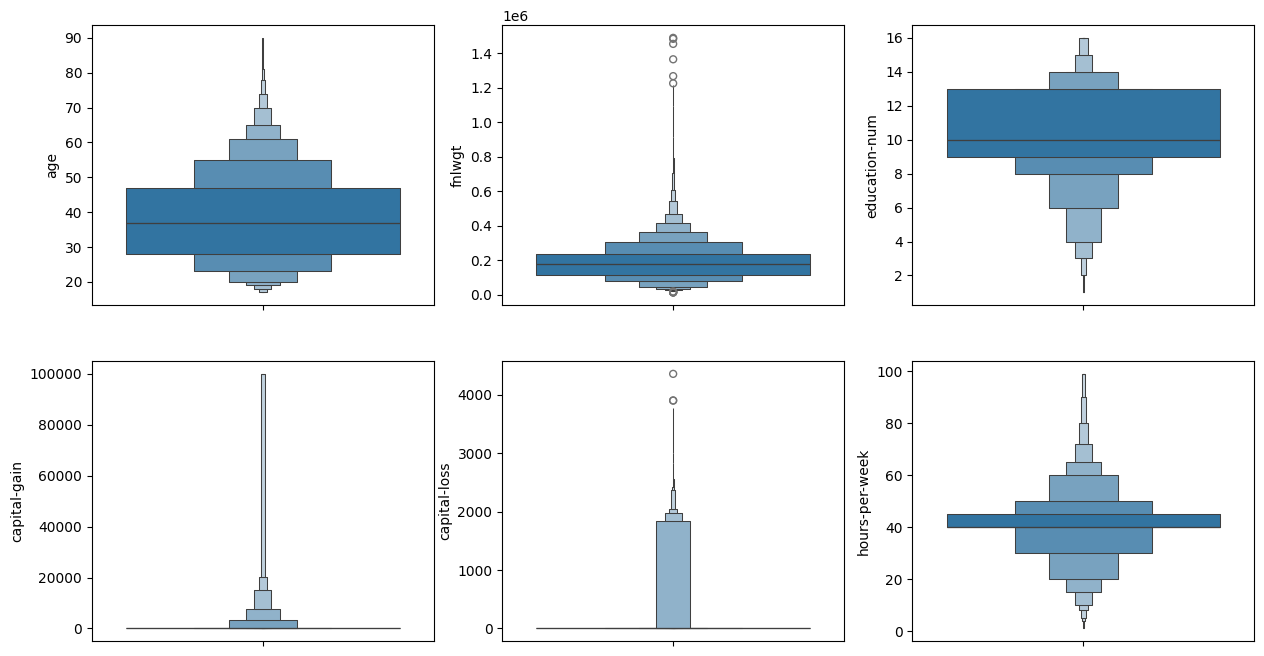

In [147]:
# visualize this via boxplot

fig, axes = plt.subplots(2, 3, figsize=(15,8))

sns.boxenplot(data=df_cp['age'], ax=axes[0,0])
sns.boxenplot(data=df_cp['fnlwgt'], ax=axes[0,1])
sns.boxenplot(data=df_cp['education-num'], ax=axes[0,2])
sns.boxenplot(data=df_cp['capital-gain'], ax=axes[1,0])
sns.boxenplot(data=df_cp['capital-loss'], ax=axes[1,1])
sns.boxenplot(data=df_cp['hours-per-week'], ax=axes[1,2])

There are too many outliers When we remove them it will effect to the Machine learnning model

In [148]:
# check it
num_of_outlier = df_cp[handle_outlier_IQR(df_cp[i])].shape[0]
num_of_data = df_cp.shape[0]

rest_of_data = num_of_data - num_of_outlier
presentage = num_of_data/num_of_outlier

print(f"Total data : {num_of_data} ")
print(f"The Outlier data : {num_of_outlier} ")
print(f"The data remain once delete outliers : {rest_of_data} ")
print(f"The remain data  as  : {presentage} ")

Total data : 45175 
The Outlier data : 11889 
The data remain once delete outliers : 33286 
The remain data  as  : 3.799730843636975 


0
